In [79]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.preprocessing import StandardScaler
import torch
from torch_geometric.data import Data
from torch_geometric.utils import from_scipy_sparse_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import NearestNeighbors
from scipy.sparse import lil_matrix
from sklearn.decomposition import TruncatedSVD

In [80]:
df = pd.read_excel("../data/Main_Data_Bank_new.xlsx")
print(df.columns.tolist())

['ID NR (anonymisert dummy)', 'Mislighold 30 og 90 dg ja/nei', 'Misligholdstype', 'Kommune', 'Fylke', 'Tilskudd i USD', 'NY tilskuddskategori', 'Bransje', 'PRODUKSJON', 'Kompleks produksjon (1/0)', 'NY KOMMUNESCORE', 'NY KOMMUNESKÅRE FRITID', 'Andre dyr', 'Annet fjørfe', 'Bær', 'Bier', 'Blomster', 'Drivhus', 'Drivhus kg', 'Egg', 'Frukt', 'Geit', 'Geitemelk', 'Gress', 'Gris', 'Griseavl', 'Grønt', 'Hest', 'Korn', 'Kylling', 'Melk', 'Pels', 'Potet', 'Salg av fõr', 'Sau', 'Storfe', 'Økologisk', 'Annet', 'Ingen', 'Produkiv skog', 'Annet fjørfe dyr', 'Bær dekar', 'Egg verpehøns', 'Frukt dekar', 'Geit dyr', 'Gress dekar', 'Gris dyr', 'Grønt dekar', 'Hest dyr', 'Korn dekar', 'Kylling dyr', 'Melk dyr', 'Potet dekar', 'Sau dyr', 'Storfe dyr', 'Bankkunde (1/0)', 'SUM UTLÅN', 'SUM RAMME', 'SUM INNSKUDD', 'ENG ja/nei', 'INNSKUDD ja/nei', 'BANK WALLET', 'BANK WALLET I MNOK', 'Har lån i bank (alle banker)', 'Kundelønnsomhet Lønnsomhet Bankr i Norge', 'Location-Leverage Mismatch Score', 'Loan-to-Produ

In [81]:
df = df.drop(columns=[
    'Bankkunde (1/0)', 'Mislighold 30 og 90 dg ja/nei', 'Misligholdstype', 
    'SUM UTLÅN', 'SUM RAMME', 'SUM INNSKUDD', 'BANK WALLET', 
    'Har lån i bank (alle banker)', 'ID NR (anonymisert dummy)', 
    'Tilskudd i USD', 'Total Production Value(NOK)', 
    'Subsidy Dependency Ratio', 'Bransje'
])
print(df.columns.tolist())

# Remove spaces and special characters from column names
df.columns = (
    df.columns
    .str.strip()
    .str.replace(" ", "_")
    .str.replace(r"[^0-9A-Za-z_]", "", regex=True)
)

# Replace “ja/nei” with 1/0
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].replace({
            'ja': 1, 'nei': 0, 
            'Ja': 1, 'Nei': 0, 
            'JA': 1, 'NEI': 0, 
            '#DIV/0!': 0
        })

# Convert the potential target column to numeric values
target_col = 'NY_tilskuddskategori'
df = df.dropna(subset=[target_col])  # Remove rows with missing values

le = LabelEncoder()
df[target_col] = le.fit_transform(df[target_col])  # Overwrite the original column



['Kommune', 'Fylke', 'NY tilskuddskategori', 'PRODUKSJON', 'Kompleks produksjon (1/0)', 'NY KOMMUNESCORE', 'NY KOMMUNESKÅRE FRITID', 'Andre dyr', 'Annet fjørfe', 'Bær', 'Bier', 'Blomster', 'Drivhus', 'Drivhus kg', 'Egg', 'Frukt', 'Geit', 'Geitemelk', 'Gress', 'Gris', 'Griseavl', 'Grønt', 'Hest', 'Korn', 'Kylling', 'Melk', 'Pels', 'Potet', 'Salg av fõr', 'Sau', 'Storfe', 'Økologisk', 'Annet', 'Ingen', 'Produkiv skog', 'Annet fjørfe dyr', 'Bær dekar', 'Egg verpehøns', 'Frukt dekar', 'Geit dyr', 'Gress dekar', 'Gris dyr', 'Grønt dekar', 'Hest dyr', 'Korn dekar', 'Kylling dyr', 'Melk dyr', 'Potet dekar', 'Sau dyr', 'Storfe dyr', 'ENG ja/nei', 'INNSKUDD ja/nei', 'BANK WALLET I MNOK', 'Kundelønnsomhet Lønnsomhet Bankr i Norge', 'Location-Leverage Mismatch Score', 'Loan-to-Production-Value Ratio', 'Production Concentration Index', 'Subsidy_Zone']


C:\Users\21059\AppData\Local\Temp\ipykernel_8876\1987256436.py:21: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].replace({


In [82]:
def generate_embeddings(df, prod_col='PRODUKSJON', region_cols=['Kommune', 'Fylke'],
                        prod_dim=16, region_dim=16):
    df = df.copy()
    
    # --- 1. Multi-label encoding + SVD compression for PRODUKSJON ---
    df[prod_col + '_list'] = df[prod_col].fillna("").apply(lambda x: [s.strip() for s in x.split(",") if s])
    mlb = MultiLabelBinarizer()
    prod_encoded = pd.DataFrame(
        mlb.fit_transform(df[prod_col + '_list']),
        columns=mlb.classes_,
        index=df.index
    )
    
    # Apply SVD for dimensionality reduction
    prod_svd = TruncatedSVD(n_components=prod_dim, random_state=42)
    prod_emb = prod_svd.fit_transform(prod_encoded)
    prod_emb_df = pd.DataFrame(
        prod_emb, 
        columns=[f'PROD_emb_{i}' for i in range(prod_dim)],
        index=df.index
    )
    
    # Merge back into df
    df = pd.concat([df, prod_emb_df], axis=1)
    df = df.drop(columns=[prod_col, prod_col + '_list'])
    
    # --- 2. One-hot encoding + SVD compression for region columns ---
    df_region = pd.get_dummies(df[region_cols], drop_first=True)
    
    region_svd = TruncatedSVD(n_components=region_dim, random_state=42)
    region_emb = region_svd.fit_transform(df_region)
    region_emb_df = pd.DataFrame(
        region_emb, 
        columns=[f'REGION_emb_{i}' for i in range(region_dim)],
        index=df.index
    )
    
    # Merge back into df
    df = pd.concat([df, region_emb_df], axis=1)
    df = df.drop(columns=region_cols)
    
    return df


In [83]:
region_cols = ['Kommune', 'Fylke']
df = generate_embeddings(df, prod_col='PRODUKSJON', region_cols=region_cols,
                         prod_dim=16, region_dim=16)

print(df.columns.tolist())
print(f"target feature '{target_col}'：")
print(df[target_col].value_counts())

['NY_tilskuddskategori', 'Kompleks_produksjon_10', 'NY_KOMMUNESCORE', 'NY_KOMMUNESKRE_FRITID', 'Andre_dyr', 'Annet_fjrfe', 'Br', 'Bier', 'Blomster', 'Drivhus', 'Drivhus_kg', 'Egg', 'Frukt', 'Geit', 'Geitemelk', 'Gress', 'Gris', 'Griseavl', 'Grnt', 'Hest', 'Korn', 'Kylling', 'Melk', 'Pels', 'Potet', 'Salg_av_fr', 'Sau', 'Storfe', 'kologisk', 'Annet', 'Ingen', 'Produkiv_skog', 'Annet_fjrfe_dyr', 'Br_dekar', 'Egg_verpehns', 'Frukt_dekar', 'Geit_dyr', 'Gress_dekar', 'Gris_dyr', 'Grnt_dekar', 'Hest_dyr', 'Korn_dekar', 'Kylling_dyr', 'Melk_dyr', 'Potet_dekar', 'Sau_dyr', 'Storfe_dyr', 'ENG_janei', 'INNSKUDD_janei', 'BANK_WALLET_I_MNOK', 'Kundelnnsomhet_Lnnsomhet_Bankr_i_Norge', 'LocationLeverage_Mismatch_Score', 'LoantoProductionValue_Ratio', 'Production_Concentration_Index', 'Subsidy_Zone', 'PROD_emb_0', 'PROD_emb_1', 'PROD_emb_2', 'PROD_emb_3', 'PROD_emb_4', 'PROD_emb_5', 'PROD_emb_6', 'PROD_emb_7', 'PROD_emb_8', 'PROD_emb_9', 'PROD_emb_10', 'PROD_emb_11', 'PROD_emb_12', 'PROD_emb_13', 'PR

In [84]:
# agri_features = [
# 'Geit_dyr', 'Gress_dekar', 'Korn_dekar', 'Melk_dyr', 'Sau_dyr', 'Storfe_dyr']

# we are choosing features to construct the graph, we try to select some important agri features)
# gnn_features = ['Kompleks_produksjon_10', 'NY_KOMMUNESCORE', 'NY_KOMMUNESKRE_FRITID', 'Andre_dyr', 'Annet_fjrfe', 'Br', 'Bier', 'Blomster', 'Drivhus', 'Drivhus_kg', 'Egg', 'Frukt', 'Geit', 'Geitemelk', 'Gress', 'Gris', 'Griseavl', 'Grnt', 'Hest', 'Korn', 'Kylling', 'Melk', 'Pels', 'Potet', 'Salg_av_fr', 'Sau', 'Storfe', 'kologisk', 'Annet', 'Ingen', 'Produkiv_skog', 'Annet_fjrfe_dyr', 'Br_dekar', 'Egg_verpehns', 'Frukt_dekar', 'Geit_dyr', 'Gress_dekar', 'Gris_dyr', 'Grnt_dekar', 'Hest_dyr', 'Korn_dekar', 'Kylling_dyr', 'Melk_dyr', 'Potet_dekar', 'Sau_dyr', 'Storfe_dyr', 'ENG_janei', 'INNSKUDD_janei', 'BANK_WALLET_I_MNOK', 'Kundelnnsomhet_Lnnsomhet_Bankr_i_Norge', 'LocationLeverage_Mismatch_Score', 'LoantoProductionValue_Ratio', 'Production_Concentration_Index', 'PROD_emb_0', 'PROD_emb_1', 'PROD_emb_2', 'PROD_emb_3', 'PROD_emb_4', 'PROD_emb_5', 'PROD_emb_6', 'PROD_emb_7', 'PROD_emb_8', 'PROD_emb_9', 'PROD_emb_10', 'PROD_emb_11', 'PROD_emb_12', 'PROD_emb_13', 'PROD_emb_14', 'PROD_emb_15', 'REGION_emb_0', 'REGION_emb_1', 'REGION_emb_2', 'REGION_emb_3', 'REGION_emb_4', 'REGION_emb_5', 'REGION_emb_6', 'REGION_emb_7', 'REGION_emb_8', 'REGION_emb_9', 'REGION_emb_10', 'REGION_emb_11', 'REGION_emb_12', 'REGION_emb_13', 'REGION_emb_14', 'REGION_emb_15']
gnn_features = ['Andre_dyr', 'Annet_fjrfe', 'Br', 'Bier', 'Blomster', 'Drivhus', 'Drivhus_kg', 'Egg', 'Frukt', 'Geit', 'Geitemelk', 'Gress', 'Gris', 'Griseavl', 'Grnt', 'Hest', 'Korn', 'Kylling', 'Melk', 'Pels', 'Potet', 'Salg_av_fr', 'Sau', 'Storfe', 'kologisk', 'Annet', 'Ingen', 'Produkiv_skog', 'Annet_fjrfe_dyr', 'Br_dekar', 'Egg_verpehns', 'Frukt_dekar', 'Geit_dyr', 'Gress_dekar', 'Gris_dyr', 'Grnt_dekar', 'Hest_dyr', 'Korn_dekar', 'Kylling_dyr', 'Melk_dyr', 'Potet_dekar', 'Sau_dyr', 'Storfe_dyr']
df = df.dropna(subset=gnn_features + [target_col])
X_graph = df[gnn_features].values
y = df[target_col].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_graph)
# important features and their weights
important_features = {
    'Korn_dekar': 3.0,   # 权重系数，可根据 CatBoost importance 调整
    'Gress_dekar': 2.5,
    'Sau_dyr': 2.0,
    'Storfe_dyr': 1.8,
    'Melk_dyr': 1.5
}
for feat, w in important_features.items():
    if feat in gnn_features:
        idx = gnn_features.index(feat)
        X_scaled[:, idx] *= w

In [85]:
k = 250
# if the similarity is higher than threshold, we add an edge
threshold = 0.8
nbrs = NearestNeighbors(n_neighbors=k+1, metric='cosine').fit(X_scaled)
distances, indices = nbrs.kneighbors(X_scaled)

# calculate cosine similarities
similarities = 1 - distances
n = X_scaled.shape[0]
A = lil_matrix((n, n))

for i in range(n):
    for j, sim in zip(indices[i][1:], similarities[i][1:]):  # 跳过自己
        if sim > threshold:
            A[i, j] = 1
            A[j, i] = 1
    if A[i].nnz == 0:
        j = indices[i][1]
        A[i, j] = 1
        A[j, i] = 1

In [86]:
degrees = np.array(A.sum(axis=1)).flatten()

print("Degree of each node:", degrees)
print("Average degree:", degrees.mean())
print("Standard deviation of degree:", degrees.std())
print("Median degree:", np.median(degrees))
print("Minimum degree:", degrees.min())
print("Maximum degree:", degrees.max())

Degree of each node: [428. 393. 334. ... 264. 425. 375.]
Average degree: 278.2889914446873
Standard deviation of degree: 98.56225498964933
Median degree: 288.0
Minimum degree: 1.0
Maximum degree: 585.0


In [87]:
edge_index, edge_attr = from_scipy_sparse_matrix(A)

data = Data(
    x=torch.tensor(X_scaled, dtype=torch.float),
    edge_index=edge_index,
    y=torch.tensor(y, dtype=torch.float)
)


In [88]:
print(data)
print(f"nodes：{data.num_nodes}")
print(f"edge：{data.num_edges}")

Data(x=[37053, 43], edge_index=[2, 10311442], y=[37053])
nodes：37053
edge：10311442


In [89]:
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv

class GraphSAGEModel(nn.Module):
    def __init__(self, in_channels, hidden, out_channels):
        super().__init__()
        self.conv1 = SAGEConv(in_channels, hidden)
        self.conv2 = SAGEConv(hidden, out_channels)

    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        x = self.conv2(x, edge_index)
        return x

model = GraphSAGEModel(in_channels=X_graph.shape[1], hidden=256, out_channels=4)

In [90]:
X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
edge_index_tensor = torch.tensor(edge_index, dtype=torch.long)  # [2, num_edges]
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
model.train()

epochs = 50
for epoch in range(epochs):
    optimizer.zero_grad()
    out = model(X_tensor, edge_index_tensor)

    row, col = edge_index_tensor
    loss = ((out[row] - out[col])**2).sum() / row.size(0)

    loss.backward()
    optimizer.step()

    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss={loss.item():.4f}")

model.eval()
with torch.no_grad():
    embeddings = model(X_tensor, edge_index_tensor).numpy()
for i in range(embeddings.shape[1]):
    df[f"gnn_emb_{i}"] = embeddings[:, i]

C:\Users\21059\AppData\Local\Temp\ipykernel_8876\4289101826.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  edge_index_tensor = torch.tensor(edge_index, dtype=torch.long)  # [2, num_edges]


Epoch 0, Loss=0.1176
Epoch 10, Loss=0.0271
Epoch 20, Loss=0.0060
Epoch 30, Loss=0.0022
Epoch 40, Loss=0.0011


--- 1. Preparing data ---
Initial feature matrix shape: (37053, 49)
Target vector shape: (37053,)

--- 1. Checking for duplicate column names ---
No duplicate column names found.

--- 2. Splitting dataset ---
Training set shape: (33347, 49)
Testing set shape: (3706, 49)

--- 3. Initializing and training CatBoost model ---
0:	learn: 1.3584653	test: 1.3583924	best: 1.3583924 (0)	total: 42ms	remaining: 1m 23s
100:	learn: 0.6107913	test: 0.6242024	best: 0.6242024 (100)	total: 3.97s	remaining: 1m 14s
200:	learn: 0.5139011	test: 0.5329116	best: 0.5329116 (200)	total: 7.87s	remaining: 1m 10s
300:	learn: 0.4742182	test: 0.4988328	best: 0.4988328 (300)	total: 11.7s	remaining: 1m 6s
400:	learn: 0.4493825	test: 0.4799630	best: 0.4799630 (400)	total: 15.5s	remaining: 1m 1s
500:	learn: 0.4283862	test: 0.4648113	best: 0.4648113 (500)	total: 19.4s	remaining: 58.1s
600:	learn: 0.4112044	test: 0.4521624	best: 0.4521624 (600)	total: 23.2s	remaining: 54s
700:	learn: 0.3963694	test: 0.4419498	best: 0.4419

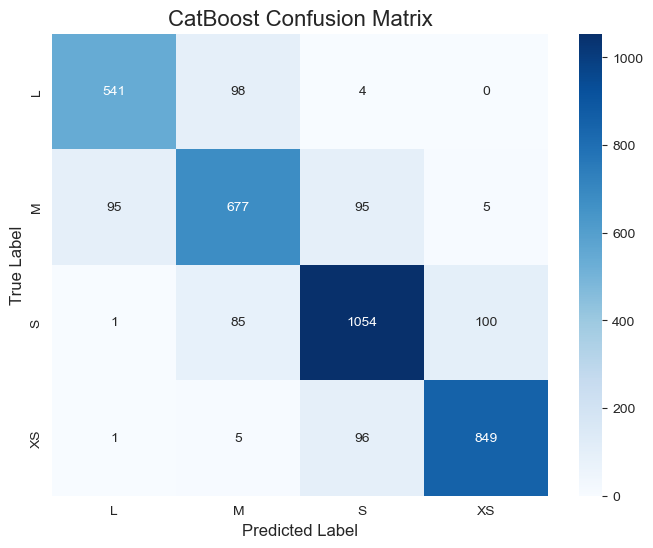


--- 5. Feature Importance Analysis ---
Top 20 Most Important Features:
                        Feature Id  Importances
0                       Korn_dekar     8.749322
1                        gnn_emb_1     8.425159
2   Production_Concentration_Index     8.147313
3                       PROD_emb_0     7.850460
4                        gnn_emb_3     6.736665
5                        gnn_emb_2     6.025246
6           Kompleks_produksjon_10     5.944419
7                        gnn_emb_0     5.472269
8                       PROD_emb_2     4.423408
9                       PROD_emb_3     4.354833
10                      PROD_emb_5     4.133324
11                      PROD_emb_1     2.980002
12                      PROD_emb_6     2.898437
13                     PROD_emb_12     1.913456
14              BANK_WALLET_I_MNOK     1.885686
15                      PROD_emb_7     1.768500
16                    Subsidy_Zone     1.550678
17                     PROD_emb_15     1.525866
18              

C:\Users\21059\AppData\Local\Temp\ipykernel_8876\1164604352.py:139: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


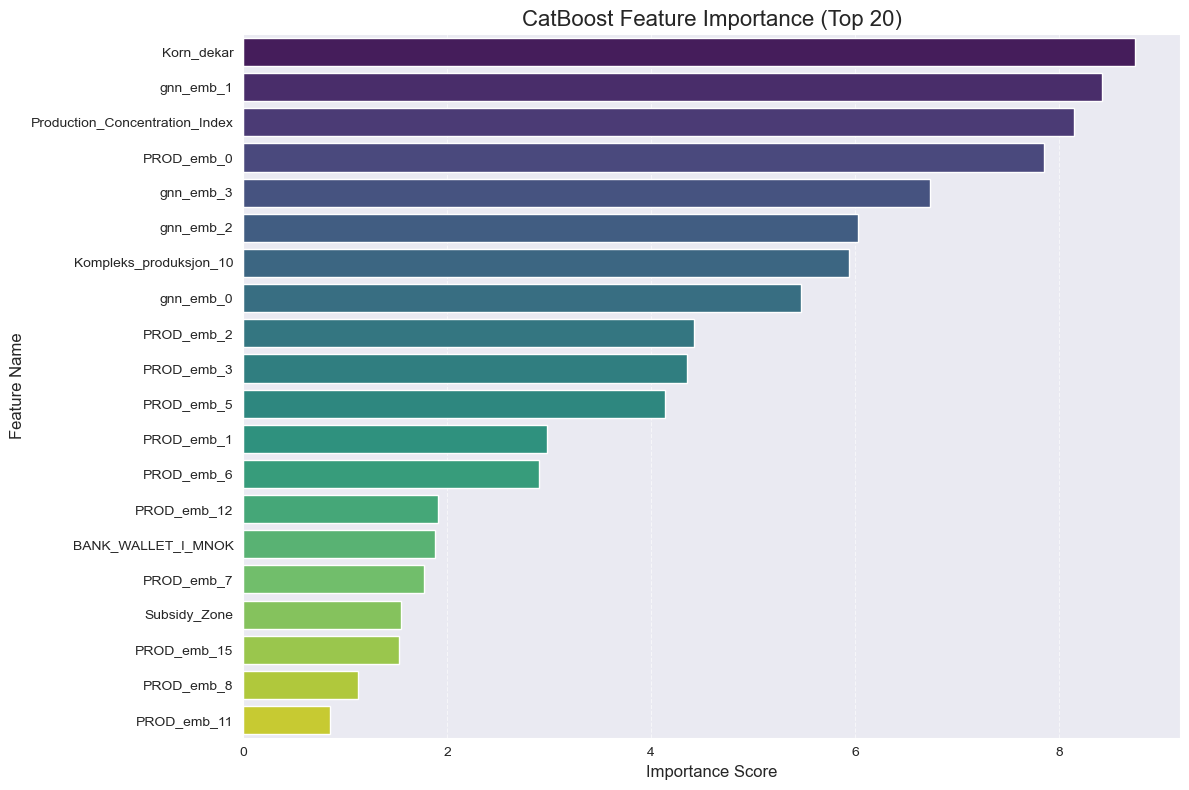

In [91]:
# If CatBoost or Seaborn are not installed, uncomment the following line:
# !pip install catboost seaborn

import pandas as pd
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report, roc_auc_score, confusion_matrix
)
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. Prepare the final dataset ---
# The dataframe `df` already contains both the original features and the GNN-generated embeddings.
# We will use this enhanced dataframe for training.

print("--- 1. Preparing data ---")
target_col = 'NY_tilskuddskategori'
# becase want to see the impact of gnn embeddings, we drop the agricultural features
X_final = df.drop(columns=[
    target_col, 'Andre_dyr', 'Annet_fjrfe', 'Br', 'Bier', 'Blomster', 'Drivhus', 'Drivhus_kg', 'Egg', 'Frukt', 'Geit', 'Geitemelk', 'Gress', 'Gris', 'Griseavl', 'Grnt', 'Hest', 'Korn', 'Kylling', 'Melk', 'Pels', 'Potet', 'Salg_av_fr', 'Sau', 'Storfe', 'kologisk', 'Annet', 'Ingen', 'Produkiv_skog', 'Annet_fjrfe_dyr', 'Br_dekar', 'Egg_verpehns', 'Frukt_dekar', 'Geit_dyr', 'Gress_dekar', 'Gris_dyr', 'Grnt_dekar', 'Hest_dyr', 'Melk_dyr', 'Potet_dekar', 'Sau_dyr', 'Storfe_dyr'
])
# X_final = df.drop(columns=[target_col])
y_final = df[target_col]

print(f"Initial feature matrix shape: {X_final.shape}")
print(f"Target vector shape: {y_final.shape}\n")


# --- 1a. Check and fix duplicate column names ---
# CatBoost requires all feature names to be unique. 
# Our preprocessing steps may have created duplicate names.

print("--- 1. Checking for duplicate column names ---")
cols = pd.Series(X_final.columns)

if cols.duplicated().any():
    print("Duplicate column names detected. Renaming...")
    duplicates = cols[cols.duplicated()].unique()
    print(f"Duplicated columns: {list(duplicates)}")
    
    # Rename duplicates by appending incremental suffixes
    col_counts = {}
    new_columns = []
    
    for col in X_final.columns:
        if col in col_counts:
            col_counts[col] += 1
            new_columns.append(f"{col}_{col_counts[col]}")
        else:
            col_counts[col] = 0
            new_columns.append(col)
    
    X_final.columns = new_columns
    print("Column renaming completed.\n")
else:
    print("No duplicate column names found.\n")


# --- 2. Train-test split ---
print("--- 2. Splitting dataset ---")
# Use stratified sampling to preserve class distribution across train/test splits.
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y_final, test_size=0.1, random_state=42, stratify=y_final
)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}\n")


# --- 3. Initialize and train CatBoost model ---
print("--- 3. Initializing and training CatBoost model ---")

model_cb = CatBoostClassifier(
    iterations=2000,           # Number of trees
    learning_rate=0.02,        # Learning rate
    depth=8,                   # Maximum tree depth
    loss_function='MultiClass', # Multi-class loss
    eval_metric='MultiClass',   # Evaluation metric
    random_seed=42,             # Random seed for reproducibility
    verbose=100                 # Log training every 100 iterations
)

# Fit the model with early stopping to avoid overfitting
model_cb.fit(
    X_train, y_train,
    eval_set=(X_test, y_test),
    early_stopping_rounds=200  # Stop if no improvement for 200 rounds
)


# --- 4. Evaluate model performance on the test set ---
print("\n--- 4. Evaluating model performance ---")

y_pred = model_cb.predict(X_test)
y_pred_proba = model_cb.predict_proba(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}")

# Multi-class ROC-AUC
roc_auc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr')
print(f"Model ROC AUC Score: {roc_auc:.4f}\n")

# Classification report
class_names = le.classes_  # Original class labels from label encoder
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=[str(c) for c in class_names]))

# Confusion matrix
print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

# Visualize confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=[str(c) for c in class_names],
    yticklabels=[str(c) for c in class_names]
)
plt.title('CatBoost Confusion Matrix', fontsize=16)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.show()


# --- 5. Feature importance analysis ---
print("\n--- 5. Feature Importance Analysis ---")

feature_importance = model_cb.get_feature_importance(prettified=True)

print("Top 20 Most Important Features:")
print(feature_importance.head(20))

# Visualize feature importance
plt.figure(figsize=(12, 8))
sns.barplot(
    x="Importances", y="Feature Id",
    data=feature_importance.head(20),
    palette="viridis"
)
plt.title('CatBoost Feature Importance (Top 20)', fontsize=16)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature Name', fontsize=12)
plt.grid(True, axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()
